# Regime-Stratified Sensitivity Analysis — Level 5L6 (isothermal)

Sensitivity of the L5L6 model (defective oxide L3 + defective metal L4 + surface kinetics L6)
**conditioned on the rate-limiting regime**, run **isothermally** at several temperatures.

## Regimes — surface / oxide / metal

`regime = argmax` of the flux-weighted resistance fractions
(`frac_surface`, `frac_oxide`, `frac_metal`), all three of which are **series** resistances.

> **Note — the parallel path is computed but not part of the label.**
> `calculate_full_model_flux_L346_v2` does model the defect bypass (pinhole / crack /
> grain-boundary, each with its own permeance), and `flux_intact` / `flux_defect` are recorded.
> But unlike the L5 study — where `defect` is a peer regime — the L5L6 label is argmax over the
> three series terms only. A run whose flux is mostly through pinholes is still labelled by
> whichever series resistance dominates the *intact* path. So an L5L6 `metal` cluster is NOT
> the same population as an L5 `metal` cluster; do not compare the two directly.

## Why isothermal

With `temperature` varying it monopolises the variance of log10(flux). A dummy-parameter test
on varying-T L5L6 clusters put temperature at **3.4-4.3x** the noise floor and, in the metal
cluster, **nothing else above 1.0x** — the runner-up (`crack_thickness_factor`) scored 0.84x,
below a random input the model never saw. L5L6 is worse than L5 here because it spreads 36
parameters over the residual variance instead of 28.

Sampling harder does not help: the floor is flat in n (0.085 at n=400, 0.092 at n=1500),
because delta's bias for an irrelevant input does not shrink with sample size. Pinning the
temperature is what lets the remaining 35 parameters compete.

Every result table carries a **`floor`** column (max delta over the dummy inputs) and
**`delta_over_floor`**. **A value at or below 1.0 is not resolved.**

> **Caveat for `theta`:** temperature does *not* dominate that metric (1.54x oxide, 0.88x
> metal), because theta is bounded [0,1] and analysed linearly. `K_eq_ref` and `H_eq` — the
> actual surface-kinetics parameters — do surface there. So theta was the one L5L6 output the
> varying-T run handled reasonably.

## Targeting

Presets are what create the study: an untargeted sweep yields essentially no surface-limited
rows. Yields measured at fixed temperature (250-draw probes) — note the surface yield more than
doubles across the range, so draw counts are sized per temperature:

| T | surface | oxide | metal |
|---|---|---|---|
| 773 K | 23.2% | 78.0% | 77.2% |
| 1073 K | 47.6% | 83.6% | 85.2% |
| 1273 K | 56.8% | 82.0% | 86.4% |

Run with the **`mace_env`** kernel (SALib pinned to 1.5.0).

In [2]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
import calculations.sensitivity as sens
importlib.reload(sens)
from calculations.config.model_config import (
    SUGGESTED_RANGES_LEVEL5L6, REGIME_PRESETS, DEFAULT_SWEEP_TEMPERATURES,
    MEASURED_YIELDS_L5L6_BY_T, ACTIVE_STUDY
)
from calculations.sensitivity import (
    REGIME_LABELS, REGIME_SA_METRICS, LOG_METRICS_DEFAULT, presets_without,
    level5L6_model_wrapper, run_targeted_regime_scans, load_regime_scans,
    plot_regime_exploration, givendata_sensitivity_by_regime, summarize_givendata,
    plot_givendata_results, regime_comparison_matrix, plot_regime_comparison_heatmap,
    plot_regime_geometry
)

# temperature is PINNED, not sampled -> it leaves the SA input set entirely
PRESETS = presets_without(REGIME_PRESETS, 'temperature')
PARAMS  = [p for p in SUGGESTED_RANGES_LEVEL5L6 if p != 'temperature']
print(f"study: {ACTIVE_STUDY}")
print(f"{len(PARAMS)} sampled parameters (temperature pinned); regimes: {REGIME_LABELS}")

study: incoloy802_cr2o3
35 sampled parameters (temperature pinned); regimes: ('surface', 'oxide', 'metal')


In [4]:
# === Run configuration ========================================================
SEED         = 42
TEMPERATURES = list(DEFAULT_SWEEP_TEMPERATURES)      # 773 / 1073 / 1273 K
TARGET_N     = 1500                                  # in-regime points per cluster
METRICS      = REGIME_SA_METRICS                     # ['flux', 'permeability', 'theta']
TOP_K        = 8

# draws = target / measured yield, per temperature. The surface yield ranges 0.23-0.57,
# so a single dict would leave the 773 K surface cluster less than half the size of the
# 1273 K one and reintroduce the cross-regime noise-floor imbalance.
N_BY_T = {T: {r: int(round(TARGET_N / MEASURED_YIELDS_L5L6_BY_T[T][r]))
              for r in REGIME_LABELS} for T in TEMPERATURES}

RESULTS_DIR     = "sa_results"
FORCE_RECOMPUTE = False
os.makedirs(RESULTS_DIR, exist_ok=True)

for T in TEMPERATURES:
    print(f"  T={T:.0f}K  draws={N_BY_T[T]}  total={sum(N_BY_T[T].values())}")
print("grand total:", sum(sum(v.values()) for v in N_BY_T.values()), "model evaluations")

  T=773K  draws={'surface': 6466, 'oxide': 1923, 'metal': 1943}  total=10332
  T=1073K  draws={'surface': 3151, 'oxide': 1794, 'metal': 1761}  total=6706
  T=1273K  draws={'surface': 2641, 'oxide': 1829, 'metal': 1736}  total=6206
grand total: 23244 model evaluations


## Phase 1 — Targeted per-regime scans, one set per temperature

Cached to `sa_results/scans/T<K>/scan_<regime>.csv`. The cache is only reused when every file
holds exactly the draw count currently requested — existence alone would silently serve a
previous configuration.

In [5]:
def cache_is_valid(paths, n_expected):
    """Reusable only if every scan exists AND matches the requested draw count."""
    for r, p in paths.items():
        if not os.path.exists(p):
            return False, f"{os.path.basename(p)} missing"
        n_have = len(pd.read_csv(p, usecols=[0]))
        if n_have != n_expected[r]:
            return False, (f"{os.path.basename(p)} holds {n_have} draws but config "
                           f"asks for {n_expected[r]}")
    return True, "every scan matches the requested draw counts"


clusters_T, scans_T, yields_T = {}, {}, {}

for T in TEMPERATURES:
    scan_dir = os.path.join(RESULTS_DIR, "scans", f"T{int(T)}")
    os.makedirs(scan_dir, exist_ok=True)
    paths = {r: os.path.join(scan_dir, f"scan_{r}.csv") for r in REGIME_LABELS}
    reusable, why = cache_is_valid(paths, N_BY_T[T])

    print(f"\n{'='*70}\nT = {T:.0f} K\n{'='*70}")
    if (not FORCE_RECOMPUTE) and reusable:
        print(f"  loading cached scans ({why})")
        cl, sc, _ = load_regime_scans(scan_dir, regimes=REGIME_LABELS)
        yl = {r: len(cl[r]) / len(sc[r]) for r in cl}
    else:
        print("  recomputing —", "FORCE_RECOMPUTE is set" if FORCE_RECOMPUTE else why)
        cl, sc, _, yl = run_targeted_regime_scans(
            N_per_regime=N_BY_T[T], regimes=REGIME_LABELS,
            presets=PRESETS, wrapper=level5L6_model_wrapper,
            fixed_params={'temperature': T},
            seed=SEED, save_dir=scan_dir, verbose=False)
    clusters_T[T], scans_T[T], yields_T[T] = cl, sc, yl
    print("  clusters:", {r: len(cl[r]) for r in REGIME_LABELS})
    print("  yields:  ", {r: f"{yl[r]*100:.1f}%" for r in REGIME_LABELS})

master = pd.concat(
    [pd.concat(clusters_T[T].values()).assign(temperature_K=T) for T in TEMPERATURES],
    ignore_index=True)
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print(f"\nmaster_clusters.csv: {len(master)} rows")


T = 773 K
  loading cached scans (every scan matches the requested draw counts)
  clusters: {'surface': 1322, 'oxide': 1456, 'metal': 1476}
  yields:   {'surface': '20.4%', 'oxide': '75.7%', 'metal': '76.0%'}

T = 1073 K
  loading cached scans (every scan matches the requested draw counts)
  clusters: {'surface': 1489, 'oxide': 1501, 'metal': 1473}
  yields:   {'surface': '47.3%', 'oxide': '83.7%', 'metal': '83.6%'}

T = 1273 K
  loading cached scans (every scan matches the requested draw counts)
  clusters: {'surface': 1440, 'oxide': 1512, 'metal': 1502}
  yields:   {'surface': '54.5%', 'oxide': '82.7%', 'metal': '86.5%'}

master_clusters.csv: 13171 rows


In [6]:
# Median outputs by temperature and regime — the physical sanity check
print(master.groupby(['temperature_K', 'regime'])[METRICS].median().to_string())

                               flux  permeability     theta
temperature_K regime                                       
773.0         metal    1.639583e-07  3.131573e-16  0.975682
              oxide    3.120468e-10  5.129541e-19  0.975432
              surface  7.367907e-11  5.393701e-16  0.008423
1073.0        metal    7.497484e-05  7.033365e-13  0.984338
              oxide    5.567211e-07  1.105861e-15  0.986995
              surface  5.932321e-09  5.588690e-13  0.001775
1273.0        metal    5.724512e-04  1.543021e-11  0.983934
              oxide    1.017626e-05  2.389911e-14  0.988770
              surface  3.024267e-08  8.560469e-12  0.000429



===== T = 773 K =====


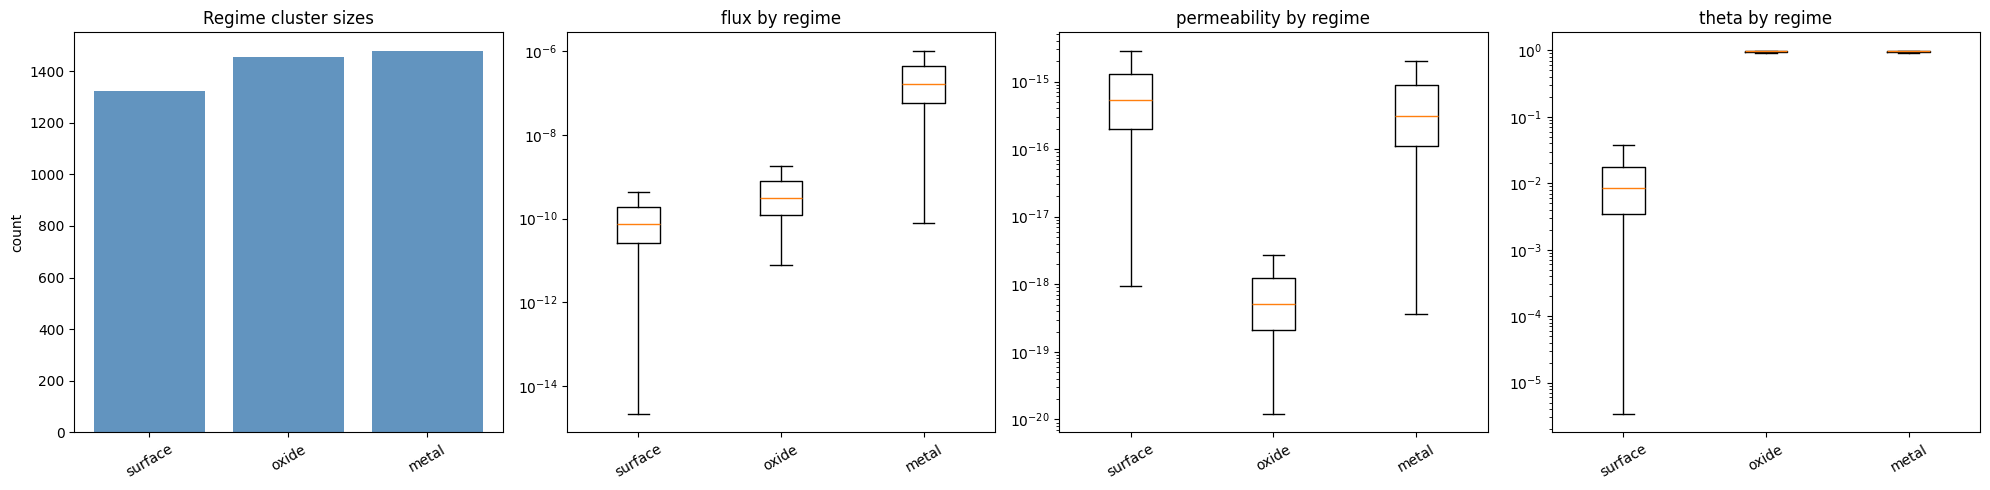


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  3075   2883    143       15
oxide                     2   1227   1665        0
surface                  35    728     14      545

===== T = 1073 K =====


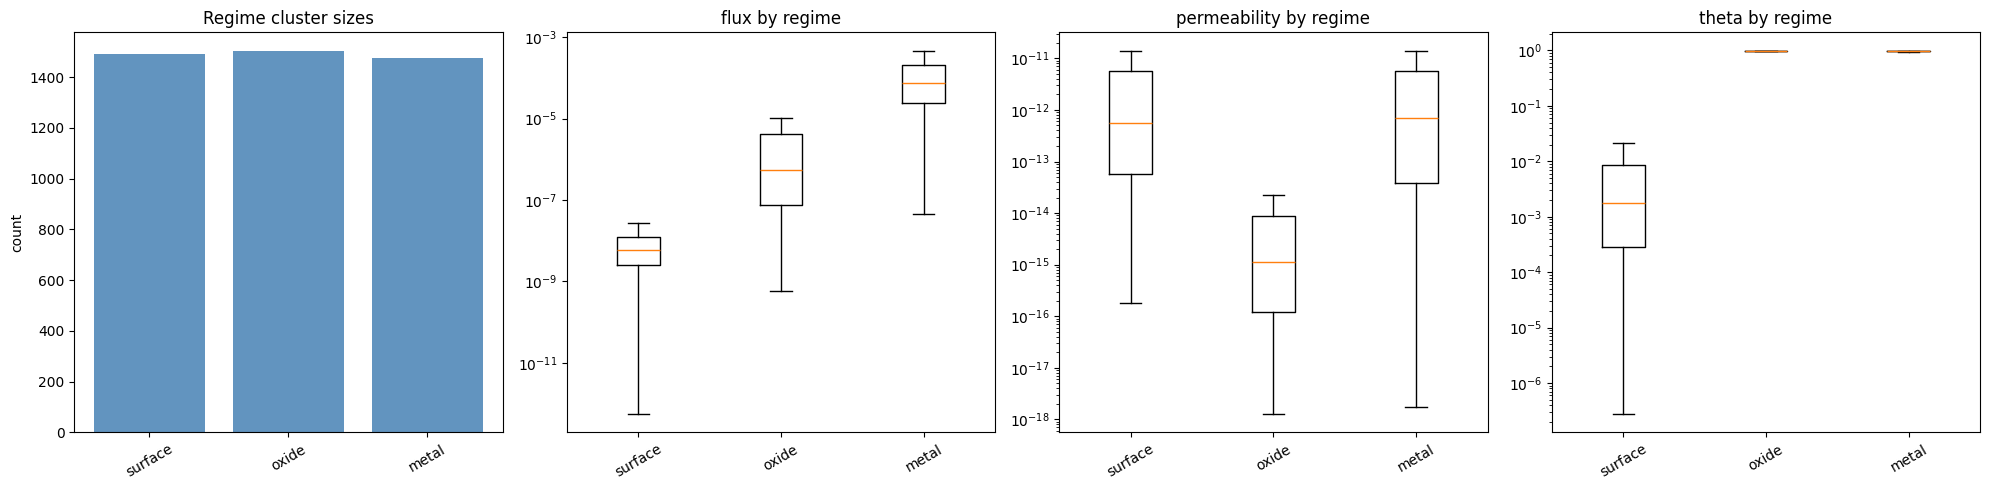


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  2393    944     36       12
oxide                     0    402   1430        0
surface                  96    588      1      804

===== T = 1273 K =====


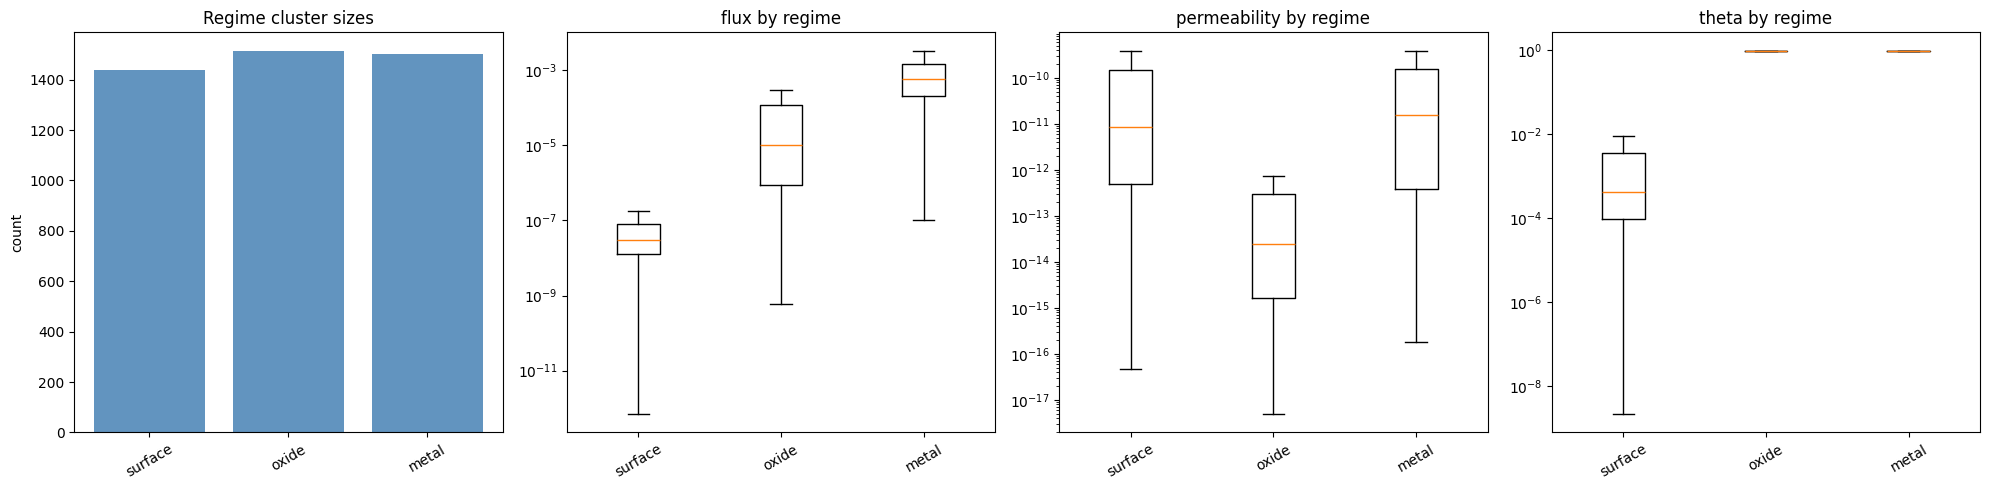


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  2301    662     42        5
oxide                     0    294   1462        0
surface                  93    356      1      990


In [7]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    plot_regime_exploration(clusters_T[T], output_metrics=tuple(METRICS),
                            scan_df=pd.concat(scans_T[T].values(), ignore_index=True),
                            cross_col='system_rate_limiting')

## Phase 2 — Route B: given-data PAWN + delta, per temperature

Zero extra model evaluations. Each `(regime, metric)` entry carries the dummy-parameter noise
`floor`; `delta_over_floor <= 1` means the parameter is **not resolved**.

In [8]:
gd_T, tidy_T = {}, {}
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    gd_T[T] = givendata_sensitivity_by_regime(
        clusters_T[T], PARAMS, output_metrics=METRICS, methods=('pawn', 'delta'),
        seed=SEED, log_metrics=LOG_METRICS_DEFAULT, n_dummy=20, verbose=True)
    tidy_T[T] = summarize_givendata(gd_T[T], PARAMS).assign(temperature_K=T)

tidy = pd.concat(tidy_T.values(), ignore_index=True)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)
print(f"\nrouteB_givendata.csv: {len(tidy)} rows")


===== T = 773 K =====
  [surface/flux] n= 1322  floor=0.095  top-δ: P_upstream (0.261)
  [surface/permeability] n= 1322  floor=0.090  top-δ: H_sol_ox (0.337)
  [surface/theta] n= 1322  floor=0.090  top-δ: H_eq (0.214)
  [oxide/flux] n= 1456  floor=0.102  top-δ: H_sol_ox (0.241)
  [oxide/permeability] n= 1456  floor=0.108  top-δ: H_sol_ox (0.365)
  [oxide/theta] n= 1456  floor=0.101  top-δ: P_upstream (0.222)
  [metal/flux] n= 1476  floor=0.103  top-δ: H_s (0.162)
  [metal/permeability] n= 1476  floor=0.091  top-δ: H_sol_ox (0.367)
  [metal/theta] n= 1476  floor=0.131  top-δ: P_upstream (0.227)

===== T = 1073 K =====
  [surface/flux] n= 1489  floor=0.113  top-δ: P_upstream (0.216)
  [surface/permeability] n= 1489  floor=0.092  top-δ: H_sol_ox (0.576)
  [surface/theta] n= 1489  floor=0.114  top-δ: H_sol_ox (0.183)
  [oxide/flux] n= 1501  floor=0.109  top-δ: H_sol_ox (0.481)
  [oxide/permeability] n= 1501  floor=0.119  top-δ: H_sol_ox (0.621)
  [oxide/theta] n= 1501  floor=0.136  top-δ:

In [9]:
# delta/floor for EVERY parameter, no threshold. A hard filter creates an artificial
# cliff (0.99 hidden, 1.01 shown) and hides how wide the noise band is.
for T in TEMPERATURES:
    for reg in REGIME_LABELS:
        sub = (tidy[(tidy.metric == 'flux') & (tidy.temperature_K == T)
                    & (tidy.regime == reg)]
               .sort_values('delta_over_floor', ascending=False))
        floor = sub['floor'].iloc[0]
        n_res = int((sub.delta_over_floor > 1.0).sum())
        print(f"  T={T:.0f}K  {reg:8s} floor={floor:.3f}  ({n_res}/{len(sub)} above 1.0x)")
        for _, r_ in sub.head(6).iterrows():
            mark = '' if r_.delta_over_floor > 1.0 else '   <- at/below noise'
            print(f"        {r_.parameter:22s} delta={r_.delta:.3f}"
                  f"  ({r_.delta_over_floor:.2f}x){mark}")
    print()

  T=773K  surface  floor=0.095  (12/35 above 1.0x)
        P_upstream             delta=0.261  (2.76x)
        D_ref                  delta=0.123  (1.30x)
        trap_vacancy_N_T       delta=0.122  (1.29x)
        f_pinhole              delta=0.108  (1.14x)
        H_s                    delta=0.107  (1.13x)
        trap_carbide_E_b       delta=0.105  (1.11x)
  T=773K  oxide    floor=0.102  (8/35 above 1.0x)
        H_sol_ox               delta=0.241  (2.37x)
        oxide_thickness        delta=0.170  (1.67x)
        D_ox_ref               delta=0.128  (1.26x)
        f_pinhole              delta=0.127  (1.24x)
        P_upstream             delta=0.123  (1.21x)
        K_ox_ref               delta=0.123  (1.21x)
  T=773K  metal    floor=0.103  (9/35 above 1.0x)
        H_s                    delta=0.162  (1.57x)
        D_ref                  delta=0.145  (1.40x)
        K_s_ref                delta=0.135  (1.31x)
        trap_vacancy_E_b       delta=0.133  (1.29x)
        trap_vaca

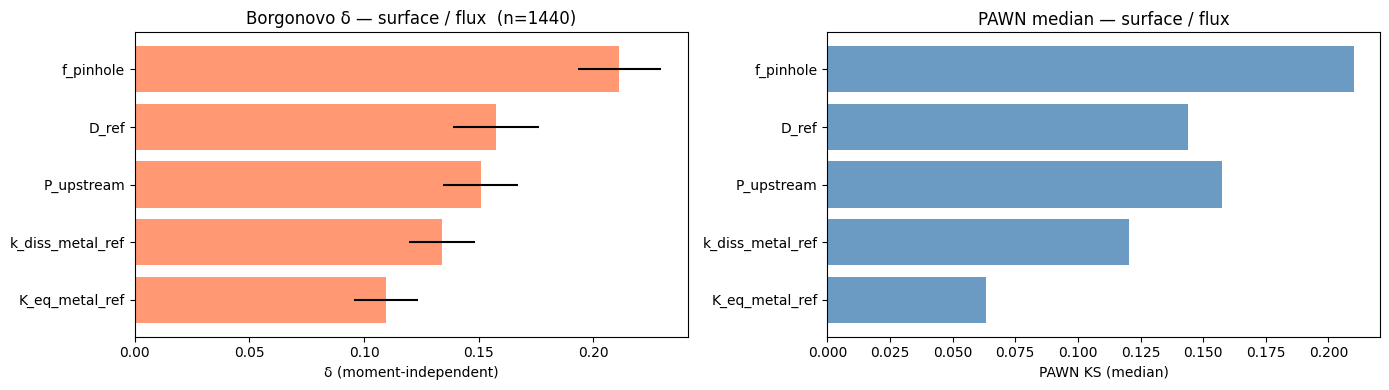

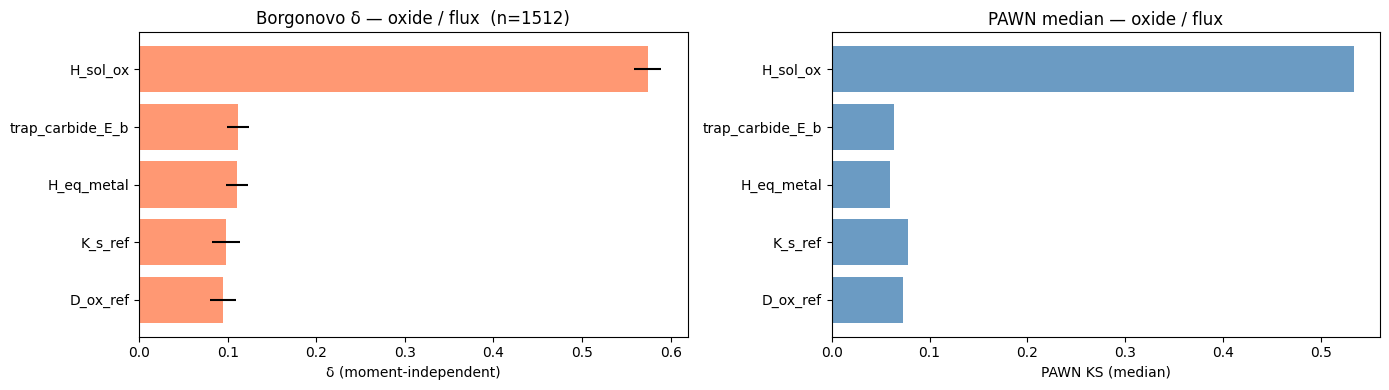

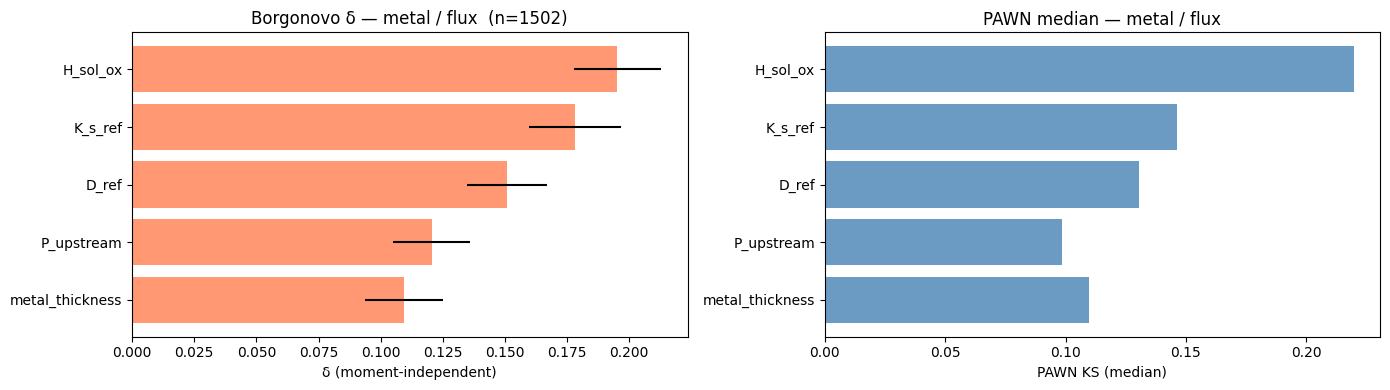

In [11]:
for reg in REGIME_LABELS:
    plot_givendata_results(gd_T[TEMPERATURES[-1]], reg, 'flux', PARAMS, top_n=5)

## Phase 2 (cont.) — regime geometry (highest temperature)

Clusters projected on their two strongest drivers. Dashed boxes are the 10-90 percentile band;
overlap is the reminder that regime boundaries are curved, not rectangular.

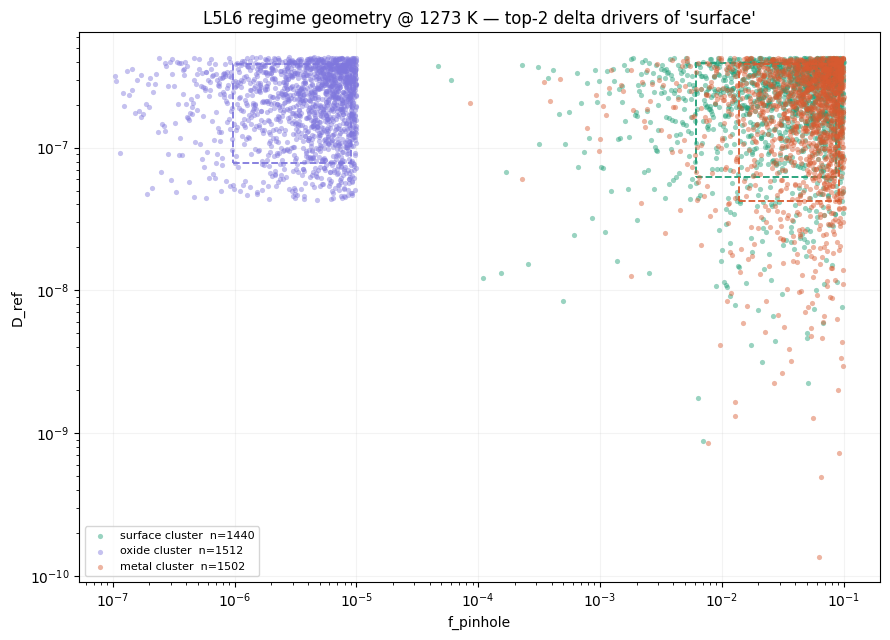

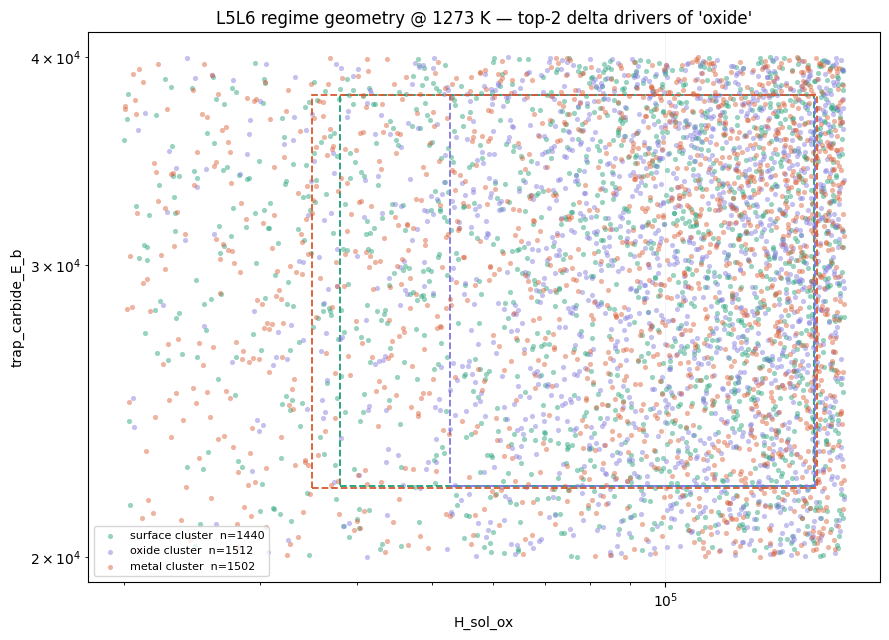

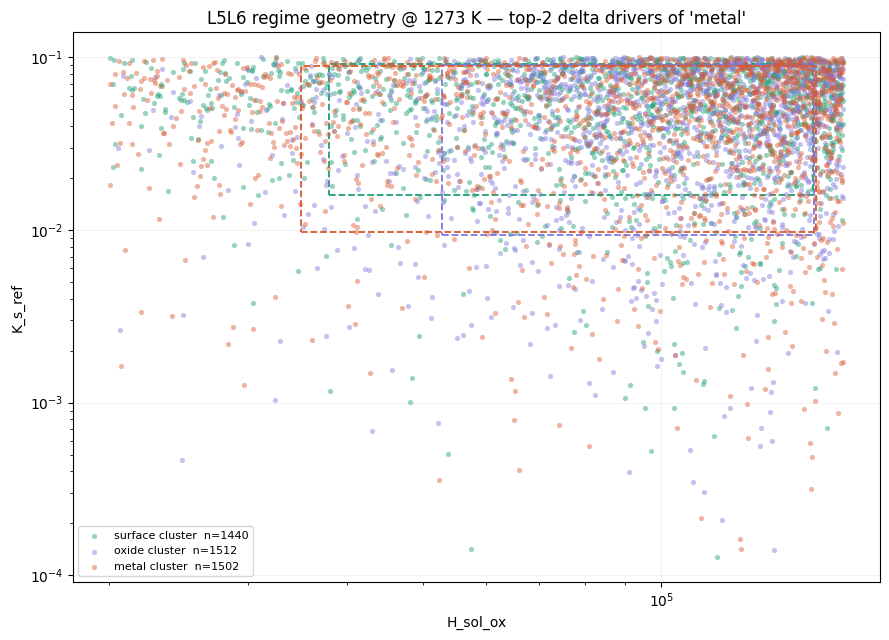

In [12]:
T_show = TEMPERATURES[-1]
def regime_topk(reg, k=TOP_K, metric='flux', T=None):
    """Top-k parameters for one regime at one temperature, ranked by Route-B delta."""
    T = T_show if T is None else T
    sub = tidy[(tidy.temperature_K == T) & (tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

for reg in REGIME_LABELS:
    plot_regime_geometry(clusters_T[T_show], axes=regime_topk(reg)[:2],
                         log_x=True, log_y=True,
                         title=f"L5L6 regime geometry @ {T_show:.0f} K — top-2 delta drivers of '{reg}'")

## Phase 3 — Cross-regime comparison, per temperature

Columns are column-normalised so each regime spans a full 0-1 scale; the small corner number is
the raw index. Exported `compare_*.csv` files are always raw.


===== T = 773 K — delta, log10(flux) =====


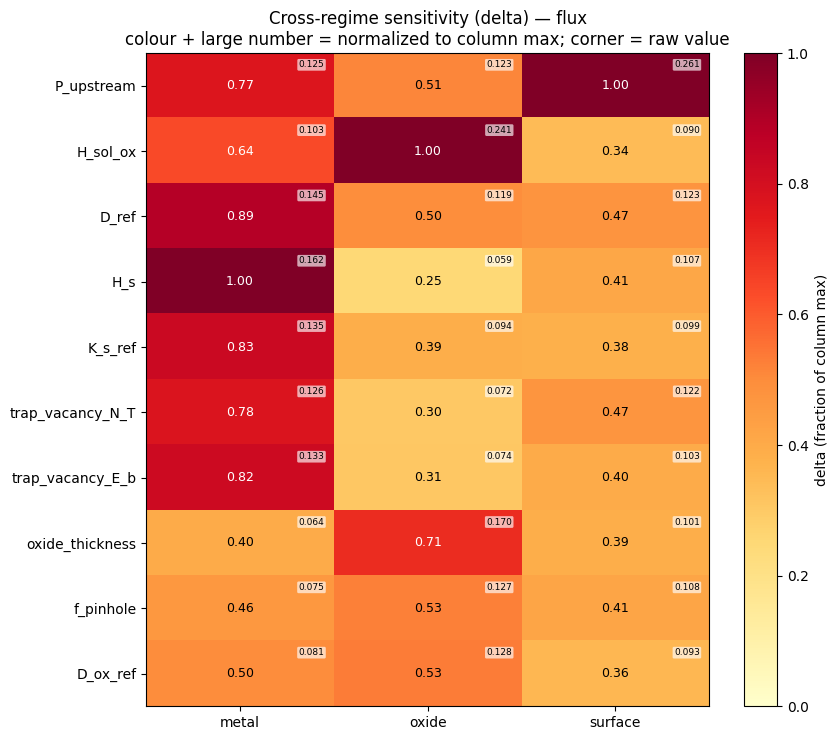


===== T = 1073 K — delta, log10(flux) =====


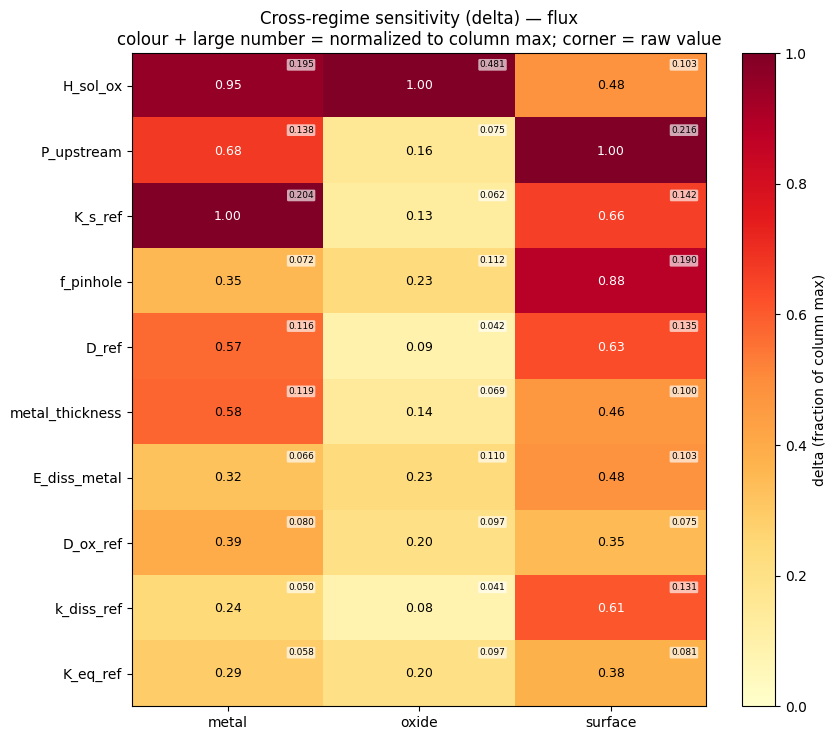


===== T = 1273 K — delta, log10(flux) =====


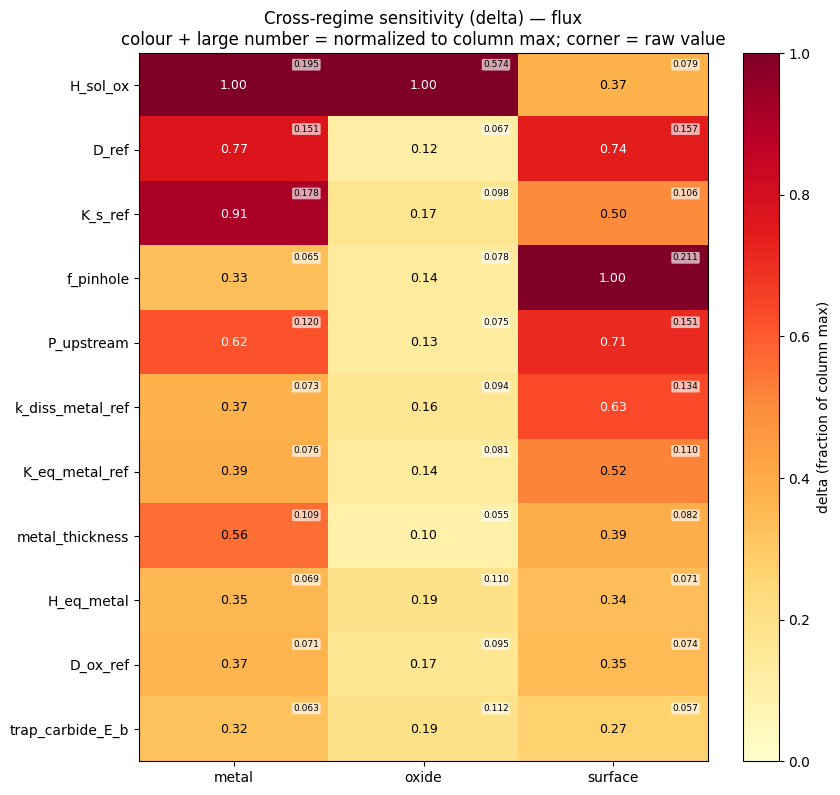

In [13]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K — delta, log10(flux) =====")
    plot_regime_comparison_heatmap(gd_T[T], 'flux', PARAMS, index='delta', top_union=5)
    for idx in ('delta', 'pawn_median'):
        for met in METRICS:
            mat = regime_comparison_matrix(gd_T[T], met, PARAMS, index=idx, top_union=5)
            if not mat.empty:
                mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}_T{int(T)}.csv"))

In [14]:
# How does each parameter's margin over the noise floor move with temperature?
# Unfiltered: every parameter appears at every T, so a value near 1.0 reads as
# "at the noise floor" instead of vanishing into a NaN that looks like missing data.
piv = (tidy[tidy.metric == 'flux']
       .pivot_table(index=['regime', 'parameter'], columns='temperature_K',
                    values='delta_over_floor'))
piv.columns = [f"{c:.0f}K" for c in piv.columns]
piv['best'] = piv.max(axis=1)

print("delta_over_floor for log10(flux) — ALL parameters, no threshold")
print("  1.0 = exactly at the dummy-parameter noise floor; higher = resolved\n")
for reg in REGIME_LABELS:
    fl = (tidy[(tidy.metric == 'flux') & (tidy.regime == reg)]
          .groupby('temperature_K')['floor'].first())
    print(f"[{reg}]  floor: " + "  ".join(f"{T:.0f}K={v:.3f}" for T, v in fl.items()))
    print(piv.loc[reg].sort_values('best', ascending=False).round(2).head(12).to_string())
    print()

piv.to_csv(os.path.join(RESULTS_DIR, "delta_over_floor_by_T.csv"))
print("saved delta_over_floor_by_T.csv")

delta_over_floor for log10(flux) — ALL parameters, no threshold
  1.0 = exactly at the dummy-parameter noise floor; higher = resolved

[surface]  floor: 773K=0.095  1073K=0.113  1273K=0.097
                  773K  1073K  1273K  best
parameter                                 
P_upstream        2.76   1.91   1.55  2.76
f_pinhole         1.14   1.68   2.17  2.17
D_ref             1.30   1.19   1.61  1.61
k_diss_metal_ref  0.77   0.69   1.38  1.38
trap_vacancy_N_T  1.29   1.08   0.93  1.29
K_s_ref           1.04   1.26   1.09  1.26
k_diss_ref        1.03   1.16   0.71  1.16
H_s               1.13   0.80   0.65  1.13
K_eq_metal_ref    0.65   0.56   1.12  1.12
trap_carbide_E_b  1.11   0.66   0.59  1.11
trap_vacancy_E_b  1.09   0.68   0.87  1.09
oxide_thickness   1.07   0.70   0.52  1.07

[oxide]  floor: 773K=0.102  1073K=0.109  1273K=0.096
                  773K  1073K  1273K  best
parameter                                 
H_sol_ox          2.37   4.42   5.97  5.97
oxide_thickness   1.67   

In [15]:
# theta is the metric temperature does NOT dominate — worth its own look
piv_t = (tidy[tidy.metric == 'theta']
         .pivot_table(index=['regime', 'parameter'], columns='temperature_K',
                      values='delta_over_floor'))
piv_t.columns = [f"{c:.0f}K" for c in piv_t.columns]
piv_t['best'] = piv_t.max(axis=1)
print("delta_over_floor for theta (surface coverage) — top 8 per regime\n")
for reg in REGIME_LABELS:
    print(f"[{reg}]")
    print(piv_t.loc[reg].sort_values('best', ascending=False).round(2).head(8).to_string())
    print()

delta_over_floor for theta (surface coverage) — top 8 per regime

[surface]
                      773K  1073K  1273K  best
parameter                                     
H_eq                  2.38   0.91   1.01  2.38
H_sol_ox              1.05   1.61   1.98  1.98
P_upstream            1.86   1.11   0.97  1.86
k_diss_ref            0.66   1.24   0.86  1.24
K_eq_ref              1.22   0.90   1.00  1.22
trap_vacancy_N_T      1.11   0.89   0.76  1.11
trap_dislocation_E_b  1.11   0.82   0.70  1.11
lattice_density       1.09   0.78   0.57  1.09

[oxide]
             773K  1073K  1273K  best
parameter                            
P_upstream   2.19   1.69   1.80  2.19
H_eq         1.82   0.73   0.72  1.82
K_eq_ref     1.53   1.49   1.63  1.63
K_ox_ref     0.77   1.06   0.69  1.06
D_ox_ref     0.77   1.03   0.83  1.03
D_ref        1.03   0.83   0.74  1.03
trap_gb_N_T  1.03   0.93   0.91  1.03
grain_size   0.68   0.98   0.77  0.98

[metal]
                 773K  1073K  1273K  best
parameter     

In [16]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")

Saved CSV files under /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/incoloy802_cr203/sa_results :
   compare_delta_flux.csv (1 KB)
   compare_delta_flux_T1073.csv (0 KB)
   compare_delta_flux_T1273.csv (0 KB)
   compare_delta_flux_T773.csv (0 KB)
   compare_delta_permeability.csv (1 KB)
   compare_delta_permeability_T1073.csv (0 KB)
   compare_delta_permeability_T1273.csv (0 KB)
   compare_delta_permeability_T773.csv (0 KB)
   compare_delta_theta.csv (1 KB)
   compare_delta_theta_T1073.csv (0 KB)
   compare_delta_theta_T1273.csv (0 KB)
   compare_delta_theta_T773.csv (0 KB)
   compare_pawn_median_flux.csv (1 KB)
   compare_pawn_median_flux_T1073.csv (0 KB)
   compare_pawn_median_flux_T1273.csv (0 KB)
   compare_pawn_median_flux_T773.csv (0 KB)
   compare_pawn_median_permeability.csv (1 KB)
   compare_pawn_median_permeability_T1073.csv (0 KB)
   compare_pawn_median_permeability_T1273.csv (0 KB)
   compare_pawn_median_permeability_T773.csv (0 KB)
   compare_p